# Phase 2 — Baseline Models with LazyClassifier

Same data and same preparation as `Phase1_Data_Exploration.ipynb`, just condensed into a few cells,
then everything is handed to **LazyClassifier** to compare many models at once.


### 0. Install / imports

In [1]:
# run once if needed
# !pip install lazypredict

In [2]:
import re
import numpy as np
import pandas as pd
from scipy.sparse import hstack
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from lazypredict.Supervised import LazyClassifier

### 1. Load the data

In [3]:
df = pd.read_csv("CEAS_08.csv")
print("Shape:", df.shape)
df.head()

Shape: (39154, 7)


,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1


### 2. Missing values (same as Phase 1)

In [4]:
df['receiver'] = df['receiver'].fillna("")
df['subject']  = df['subject'].fillna("No Subject")

for col in ["sender", "receiver", "subject", "body"]:
    df[col] = (df[col].astype(str)
                      .str.strip()
                      .str.replace(r"\s+", " ", regex=True))

print(df.isna().sum())

sender      0
receiver    0
date        0
subject     0
body        0
label       0
urls        0
dtype: int64


### 3. Feature engineering (date features only)

`receiver_spam_ratio` from Phase 1 is **dropped** here: it is derived from the target, so it leaks.
Keeping it pushes every model to ~99.7% and leaves nothing to compare.

In [5]:
# NOTE: Phase 1 built a 'receiver_spam_ratio' feature (share of a receiver's mail that is spam).
# We deliberately do NOT build it here -- it is computed from the label column across the whole
# dataset, so it leaks the target. 3,667 of 3,693 receivers are 100% one class, and 1,742
# receivers appear exactly once, meaning the feature equals that row's own label.

# date -> hour + day of week
df['date_clean'] = pd.to_datetime(df['date'], errors='coerce', utc=True)
df = df.dropna(subset=['date_clean'])
df['hour'] = df['date_clean'].dt.hour
df['day_of_week'] = df['date_clean'].dt.day_name()

df = df.drop(columns=['sender', 'receiver', 'date', 'date_clean'])
print("Shape:", df.shape)

Shape: (39139, 6)


### 4. Text features (counts) then drop the raw columns

In [6]:
df['combined_text'] = df['subject'] + ' ' + df['body']

spammy_chars = "@#$%^&*()_+=[]{}|\\<>~"
df['capital_letter_count'] = df['combined_text'].str.count(r'[A-Z]')
df['capital_ratio']        = df['capital_letter_count'] / (df['combined_text'].str.len() + 1)
df['exclamation_count']    = df['combined_text'].str.count(r'!')
df['question_count']       = df['combined_text'].str.count(r'\?')
df['special_char_count']   = df['combined_text'].apply(lambda x: sum(c in spammy_chars for c in x))

df = df.drop(columns=['subject', 'body'])
df = pd.get_dummies(df, columns=['day_of_week'], dtype=int)
df.head()

,label,urls,hour,combined_text,capital_letter_count,capital_ratio,exclamation_count,question_count,special_char_count,day_of_week_Friday,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,1,1,23,"Never agree to be a loser Buck up, your troubl...",7,0.023490,2,0,0,0,0,0,0,0,1,0
1,1,1,23,Befriend Jenna Jameson Upgrade your sex and pl...,4,0.039216,0,0,0,0,0,0,0,0,1,0
2,1,1,8,CNN.com Daily Top 10 >+=+=+=+=+=+=+=+=+=+=+=+=...,650,0.176009,0,15,273,0,0,0,0,0,0,1
3,0,1,23,Re: svn commit: r619753 - in /spamassassin/tru...,197,0.008091,4,75,2616,0,0,0,0,0,1,0
4,1,1,23,SpecialPricesPharmMoreinfo WelcomeFastShipping...,40,0.201005,0,0,2,0,0,0,0,0,1,0


### 5. Text cleaning (same steps as Phase 1, in one function)

In [7]:
def clean_text(text):
    text = str(text)
    text = re.sub(r'<.*?>', '', text)                                  # HTML tags
    text = re.sub(r'http\S+|www\.\S+', '', text)                       # URLs
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b', 'EMAIL', text)
    text = re.sub(r'\b([\w\-./\\]+)(\.[A-Za-z0-9]+)\b', r'FILE\2', text)  # keep extension
    text = re.sub(r"(FILE)\.(\w+)|[^A-Za-z0-9\s']",
                  lambda m: m.group(0) if m.group(1) else ' ', text)  # punctuation, keep FILE.ext
    text = re.sub(r'\b(?=\w*[A-Za-z])(?=\w*\d)\w+\b', 'HASH', text)     # random codes
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return text

df['combined_text'] = df['combined_text'].apply(clean_text)
df['combined_text'].head(2).tolist()

['never agree to be a loser buck up your troubles caused by small dimension will soon be over become a lover no woman will be able to resist come even as nazi tanks were rolling down the streets the dreamersphilosopher or a journalist he was still not file.i do the same',
 'befriend jenna jameson upgrade your sex and pleasures with these techniques']

### 6. Train / test split + TF-IDF + scaling

In [8]:
text_col = "combined_text"
y_col = "label"

numeric_cols = [c for c in df.columns if c not in [text_col, y_col]]
print("Numeric columns:", numeric_cols)

train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df[y_col], random_state=42
)

tfidf = TfidfVectorizer(max_features=300, ngram_range=(1, 2), stop_words='english')
X_train_text = tfidf.fit_transform(train_df[text_col])
X_test_text  = tfidf.transform(test_df[text_col])

scaler = StandardScaler(with_mean=False)
X_train_num = scaler.fit_transform(train_df[numeric_cols])
X_test_num  = scaler.transform(test_df[numeric_cols])

X_train = hstack([X_train_text, X_train_num], format='csr')
X_test  = hstack([X_test_text,  X_test_num],  format='csr')
y_train = train_df[y_col].values
y_test  = test_df[y_col].values

print("X_train:", X_train.shape, " X_test:", X_test.shape)

Numeric columns: ['urls', 'hour', 'capital_letter_count', 'capital_ratio', 'exclamation_count', 'question_count', 'special_char_count', 'day_of_week_Friday', 'day_of_week_Monday', 'day_of_week_Saturday', 'day_of_week_Sunday', 'day_of_week_Thursday', 'day_of_week_Tuesday', 'day_of_week_Wednesday']
X_train: (31311, 314)  X_test: (7828, 314)


### 7. LazyClassifier

With TF-IDF capped at 300 the whole matrix is only ~314 columns, so we can hand it to
LazyClassifier directly -- no feature selection needed. Two notes:

* LazyClassifier **cannot take a sparse matrix** (it calls `select_dtypes()`, a DataFrame method),
  so we densify with `.toarray()`.
* We fit on a sample of the training rows to keep ~30 models fast; the full test set is used.

In [9]:
SAMPLE = 8000   # training rows for the comparison (set to None to use all)

rng = np.random.default_rng(42)
if SAMPLE and SAMPLE < X_train.shape[0]:
    idx = rng.choice(X_train.shape[0], SAMPLE, replace=False)
    X_fit, y_fit = X_train[idx], y_train[idx]
else:
    X_fit, y_fit = X_train, y_train

# LazyClassifier calls select_dtypes() on its input, so it needs a dense DataFrame,
# not the sparse matrix that hstack produces.
X_fit  = pd.DataFrame(X_fit.toarray())
X_eval = pd.DataFrame(X_test.toarray())

print("Fitting on:", X_fit.shape, " Evaluating on:", X_eval.shape)

clf = LazyClassifier(verbose=0, ignore_warnings=True, predictions=False)
models, predictions = clf.fit(X_fit, X_eval, y_fit, y_test)
models

Fitting on: (8000, 314)  Evaluating on: (7828, 314)


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
ExtraTreesClassifier,0.986842,0.986769,0.999029,0.986843,0.986846,0.986842,2.552615
RandomForestClassifier,0.986842,0.986560,0.998939,0.986841,0.986841,0.986842,1.766721
BaggingClassifier,0.979433,0.979319,0.993815,0.979436,0.979443,0.979433,3.049929
SVC,0.979561,0.978896,0.995214,0.979552,0.979566,0.979561,9.498279
DecisionTreeClassifier,0.974323,0.973841,0.973841,0.974319,0.974319,0.974323,0.616047
LogisticRegression,0.972407,0.971585,0.993575,0.972394,0.972410,0.972407,0.391244
LinearSVC,0.970746,0.969738,0.991655,0.970727,0.970763,0.970746,1.134796
PassiveAggressiveClassifier,0.969085,0.969236,0.992476,0.969102,0.969165,0.969085,0.288328
CalibratedClassifierCV,0.969341,0.967371,0.993135,0.969287,0.969583,0.969341,3.184614


### 8. Results

In [10]:
models.sort_values("F1 Score", ascending=False).head(10)

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
ExtraTreesClassifier,0.986842,0.986769,0.999029,0.986843,0.986846,0.986842,2.552615
RandomForestClassifier,0.986842,0.986560,0.998939,0.986841,0.986841,0.986842,1.766721
SVC,0.979561,0.978896,0.995214,0.979552,0.979566,0.979561,9.498279
BaggingClassifier,0.979433,0.979319,0.993815,0.979436,0.979443,0.979433,3.049929
DecisionTreeClassifier,0.974323,0.973841,0.973841,0.974319,0.974319,0.974323,0.616047
LogisticRegression,0.972407,0.971585,0.993575,0.972394,0.972410,0.972407,0.391244
LinearSVC,0.970746,0.969738,0.991655,0.970727,0.970763,0.970746,1.134796
CalibratedClassifierCV,0.969341,0.967371,0.993135,0.969287,0.969583,0.969341,3.184614
PassiveAggressiveClassifier,0.969085,0.969236,0.992476,0.969102,0.969165,0.969085,0.288328


(0.5, 1.0)

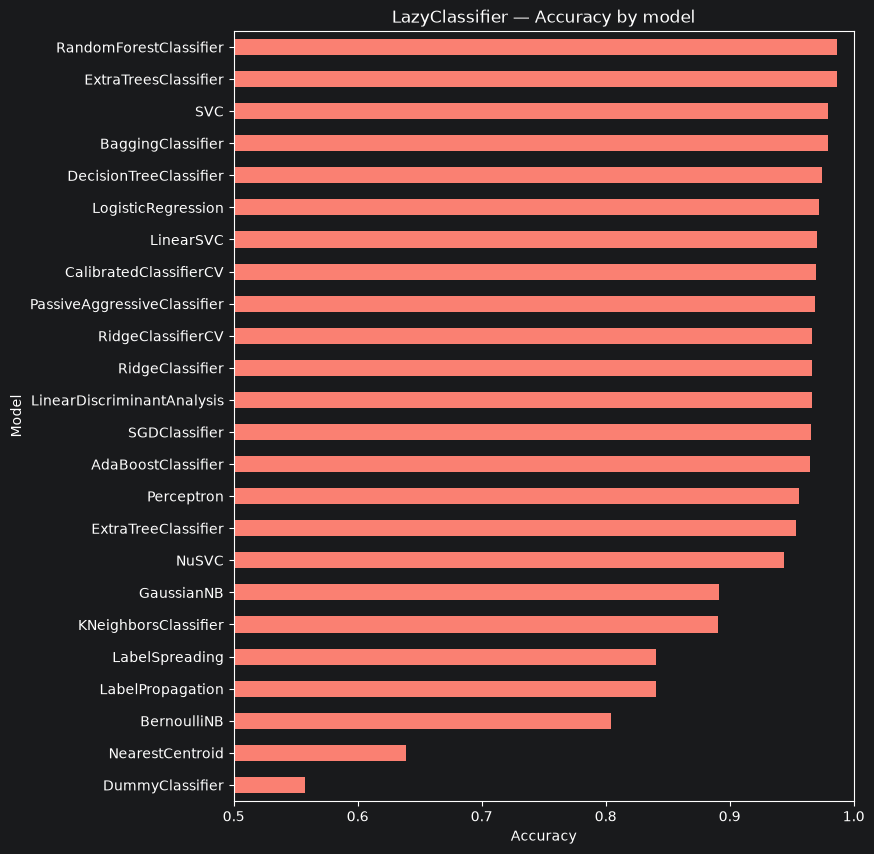

In [11]:
ax = models["Accuracy"].sort_values().plot(
    kind="barh", figsize=(8, 10), color="salmon", title="LazyClassifier — Accuracy by model"
)
ax.set_xlabel("Accuracy")
ax.set_xlim(0.5, 1.0)

**Next step:** take the top 2–3 models from this table and tune them properly in Phase 3.